# Modelo CNN (Baseline)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install lazrs laszip laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 649.3/649.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
import os
import laspy
import numpy as np
import pandas as pd
from skimage.transform import resize

In [ ]:
# Pegamos cada talhão dos dados LiDAR coletados
laz_files = sorted([
    f for f in os.listdir("/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR")
    if f.endswith(".laz")
])

print(laz_files)

['SaoManuelTotal_001.laz', 'SaoManuelTotal_002.laz', 'SaoManuelTotal_004.laz', 'SaoManuelTotal_005.laz', 'SaoManuelTotal_006.laz', 'SaoManuelTotal_007.laz']


In [ ]:
# Criamos listas para armazenar a entrada X(imagens chm), o valor real da altura, os IDs de cada parcela dentro dos talhões e os IDs dos talhões
X = []
y_dap = []
parcelas_ids = []
talhoes_ids = []

In [ ]:
import geopandas as gpd

gdf = gpd.read_file(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/shapes/Parcelas/parcelas.shp"
)

gdf["talhao"] = (
    gdf["talhao"]
    .astype(str)
    .str.zfill(3)
)

gdf["parcela"] = (
    gdf["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(gdf.head())

print(gdf["talhao"].unique())

   id     elev parcela talhao     Fazenda        Especie Mat_gen  \
0   1  738.637     001    001  São Manuel  Eucalyptus sp    I144   
1   2  739.195     002    001  São Manuel  Eucalyptus sp    I144   
2   3  774.722     003    003  São Manuel           None    None   
3   4  781.896     004    004  São Manuel  Eucalyptus sp    None   
4   5  776.755     005    004  São Manuel  Eucalyptus sp    None   

                                   geometry  
0  POINT Z (749049.463 7480009.299 738.637)  
1   POINT Z (748983.36 7480013.776 739.195)  
2  POINT Z (748849.993 7479561.952 774.722)  
3  POINT Z (748836.068 7479441.914 781.896)  
4  POINT Z (748827.399 7479324.807 776.755)  
['001' '003' '004' '002' '005' '008' '006' '007']


In [ ]:
def create_chm(points, resolution=0.2):

    x = points[:,0]
    y = points[:,1]
    z = points[:,2]

    xmin = x.min()
    xmax = x.max()

    ymin = y.min()
    ymax = y.max()

    width = int((xmax - xmin) / resolution) + 1
    height = int((ymax - ymin) / resolution) + 1

    chm = np.zeros((height, width))

    xi = ((x - xmin) / resolution).astype(int)
    yi = ((y - ymin) / resolution).astype(int)

    for i in range(len(points)):

        if z[i] > chm[yi[i], xi[i]]:
            chm[yi[i], xi[i]] = z[i]

    return chm

In [ ]:
def sample_points(points, n_points=2048, seed=42):
    rng = np.random.default_rng(seed)
    if len(points) >= n_points:
        idx = rng.choice(
            len(points),
            n_points,
            replace=False
        )
    else:
        idx = rng.choice(
            len(points),
            n_points,
            replace=True
        )
    return points[idx]

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/SaoManuelTotal_08022025_plot_metric.csv"
)

df["parcela"] = (
    df["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(df[["parcela", "D_cm"]].head())

  parcela  D_cm
0     001  17.6
1     002  16.8
2     004  12.9
3     005  13.8
4     006  13.8


In [ ]:
for laz_file in laz_files:
    print("Processando dados .laz:", laz_file)

    talhao = laz_file.split("_")[-1].replace(".laz","")

    las_path = os.path.join(
        "/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR",
        laz_file
    )

    las = laspy.read(las_path)

    x_lidar = np.array(las.x)
    y_lidar = np.array(las.y)
    z_lidar = np.array(las.z)

    points = np.vstack(
        (x_lidar, y_lidar, z_lidar)
    ).transpose()

    gdf_talhao = gdf[
        gdf["talhao"] == talhao
    ]

    print("Parcelas encontradas:", len(gdf_talhao))

    for idx, row in gdf_talhao.iterrows():

        geom = row.geometry

        cx = geom.x
        cy = geom.y

        radius = 11.28

        dist = np.sqrt(
            (x_lidar - cx)**2 +
            (y_lidar - cy)**2
        )

        mask = dist <= radius

        crop = points[mask]

        print(
            f"Parcela {row['parcela']} = {crop.shape}"
        )

        if len(crop) < 100:
            continue

        try:

            crop = sample_points(
                crop,
                n_points=2048
            )

            chm = create_chm(crop)

            chm = resize(
                chm,
                (128,128),
                preserve_range=True
            )

            if chm.max() > 0:
                chm = chm / chm.max()

            parcela = str(
                row["parcela"]
            ).zfill(3)

            dap_row = df[
                df["parcela"] == parcela
            ]

            if len(dap_row) == 0:
                continue

            dap = dap_row["D_cm"].values[0]

            X.append(chm)

            y_dap.append(dap)

            parcelas_ids.append(parcela)

            talhoes_ids.append(talhao)

            print(
                f"DAP = {dap}"
            )

        except Exception as e:

            print("Erro.", e)

Processando dados .laz: SaoManuelTotal_001.laz
Parcelas encontradas: 2
Parcela 001 = (187159, 3)
DAP = 17.6
Parcela 002 = (169624, 3)
DAP = 16.8
Processando dados .laz: SaoManuelTotal_002.laz
Parcelas encontradas: 2
Parcela 006 = (264621, 3)
DAP = 13.8
Parcela 007 = (225852, 3)
DAP = 16.0
Processando dados .laz: SaoManuelTotal_004.laz
Parcelas encontradas: 2
Parcela 004 = (332656, 3)
DAP = 12.9
Parcela 005 = (248728, 3)
DAP = 13.8
Processando dados .laz: SaoManuelTotal_005.laz
Parcelas encontradas: 2
Parcela 008 = (450272, 3)
DAP = 17.6
Parcela 009 = (161647, 3)
DAP = 16.7
Processando dados .laz: SaoManuelTotal_006.laz
Parcelas encontradas: 3
Parcela 010 = (394402, 3)
DAP = 17.8
Parcela 011 = (304549, 3)
DAP = 17.0
Parcela 012 = (261158, 3)
DAP = 17.4
Processando dados .laz: SaoManuelTotal_007.laz
Parcelas encontradas: 2
Parcela 013 = (266162, 3)
DAP = 17.4
Parcela 014 = (294639, 3)
DAP = 20.4


In [ ]:
X = np.array(X)

y_dap = np.array(y_dap)

print(X.shape)
print(y_dap.shape)

(13, 128, 128)
(13,)


In [ ]:
X = X[:, np.newaxis, :, :]

In [ ]:
from sklearn.model_selection import KFold
import pickle
# Divimos em 5 folds para garantir generalização em diferentes parcelas
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    kf.split(y_dap)
)

In [ ]:
print(X.shape)

(13, 1, 128, 128)


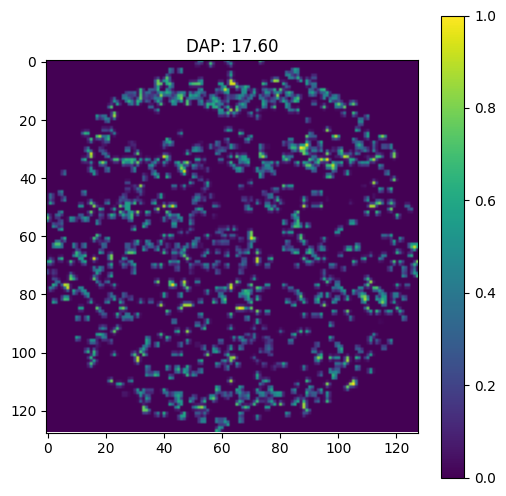

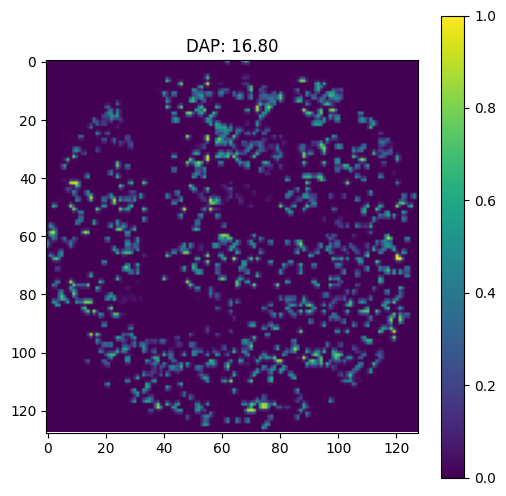

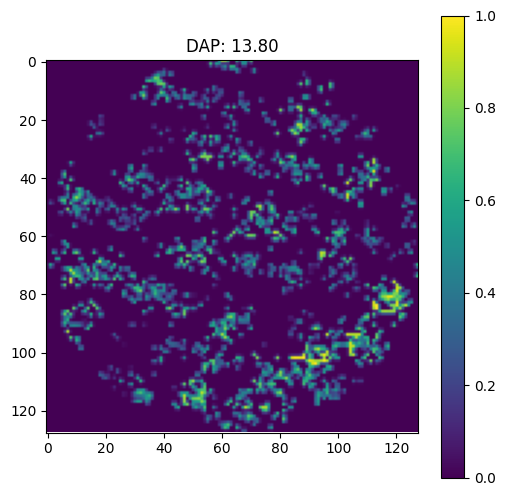

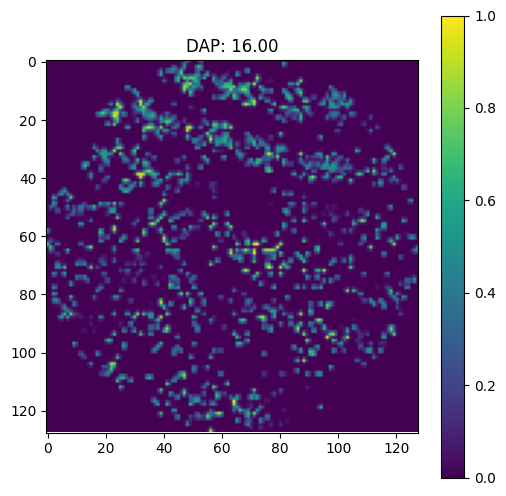

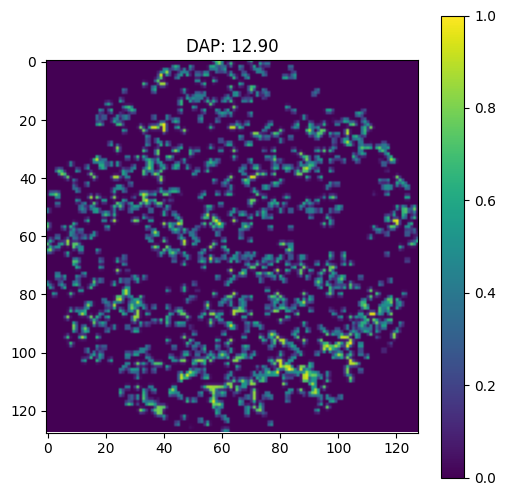

In [ ]:
import matplotlib.pyplot as plt

for i in range(min(5, len(X))):

    plt.figure(figsize=(6,6))

    plt.imshow(
        X[i][0],
        cmap="viridis"
    )

    plt.title(
        f"DAP: {y_dap[i]:.2f}"
    )

    plt.colorbar()

    plt.show()

In [ ]:
import random
import numpy as np
import torch
# set seed para garantir que a semente é fixa
def set_seed(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [ ]:
import torch.nn as nn
# CNN com 3 camadas convolucionais
class CNNRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128,1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)

        return x

In [ ]:
import time
import psutil
import os

import pandas as pd
# Import de métricas
from sklearn.model_selection import KFold

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
all_targets = []
all_predictions = []
all_folds = []
results = []

In [ ]:
for fold, (train_idx, test_idx) in enumerate(folds):
    # Para cada fold treinamos e vemos os resultados
    print("\n")
    print(f"FOLD {fold+1}")
    set_seed(42)

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y_dap[train_idx]
    y_test = y_dap[test_idx]

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).view(-1,1)

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    ).view(-1,1)

    train_dataset = TensorDataset(
        X_train,
        y_train
    )

    test_dataset = TensorDataset(
        X_test,
        y_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=2,
        shuffle=False
    )

    model = CNNRegressor()

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    start_train = time.time()
    num_epochs = 50

    for epoch in range(num_epochs):

        model.train()

        for images, targets_batch in train_loader:

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(
                outputs,
                targets_batch
            )
            loss.backward()
            optimizer.step()

    end_train = time.time()
    training_time = (end_train - start_train)
    predictions = []
    targets = []
    start_inf = time.time()
    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            outputs = model(images)
            predictions.extend(
                outputs.numpy().flatten()
            )
            targets.extend(
                labels.numpy().flatten()
            )

    end_inf = time.time()
    total_inf_time = (end_inf - start_inf)
    latency = (total_inf_time / len(test_dataset))
    throughput = (len(test_dataset) / total_inf_time)
    fps = 1 / latency
    mae = mean_absolute_error(targets, predictions)
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    mape = np.mean(np.abs((np.array(targets) - np.array(predictions)) / np.array(targets))) * 100
    bias = np.mean(np.array(predictions) - np.array(targets))
    rrmse = (rmse / np.mean(targets)) * 100
    process = psutil.Process(os.getpid())
    memory_mb = (process.memory_info().rss/1024**2)
    total_params = sum(p.numel() for p in model.parameters())

    results.append({

        "fold": fold + 1,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "bias": bias,
        "rrmse": rrmse,
        "latency": latency,
        "throughput": throughput,
        "fps": fps,
        "memory_mb": memory_mb,
        "params": total_params,
        "training_time": training_time

    })

    for t, p in zip(targets, predictions):

        all_targets.append(t)
        all_predictions.append(p)
        all_folds.append(fold + 1)

    print(
        f"MAE={mae:.3f}"
        f" RMSE={rmse:.3f}"
    )



FOLD 1
MAE=1.685 RMSE=1.808


FOLD 2
MAE=2.065 RMSE=2.636


FOLD 3
MAE=3.178 RMSE=3.441


FOLD 4
MAE=0.929 RMSE=1.309


FOLD 5
MAE=1.056 RMSE=1.061


In [ ]:
results_df = pd.DataFrame(results)

display(results_df)

,fold,mae,rmse,mape,bias,rrmse,latency,throughput,fps,memory_mb,params,training_time
0,1,1.685277,1.807517,9.758973,-1.685277,10.427980,0.012867,77.720272,77.720272,1407.386719,2120705,14.954858
1,2,2.064829,2.635822,14.928683,2.023263,17.417328,0.007976,125.382757,125.382757,1415.386719,2120705,14.583912
2,3,3.178103,3.440735,19.766117,-0.565487,20.603207,0.007809,128.057317,128.057317,1415.386719,2120705,14.591225
3,4,0.928818,1.308736,5.338857,-0.928818,7.675871,0.006734,148.489335,148.489335,1415.539062,2120705,16.359922
4,5,1.055857,1.061213,6.268893,-0.106485,6.316743,0.007473,133.815212,133.815212,1423.539062,2120705,16.562757


In [ ]:
summary = pd.DataFrame({
    "Media": results_df.mean(
        numeric_only=True
    ),
    "Std": results_df.std(
        numeric_only=True
    )
})
display(summary)

,Media,Std
fold,3.000000e+00,1.581139
mae,1.782577e+00,0.907421
rmse,2.050805e+00,0.982764
mape,1.121231e+01,6.083298
bias,-2.525608e-01,1.397197
rrmse,1.248823e+01,6.237779
latency,8.571744e-03,0.002448
throughput,1.226930e+02,26.681976
fps,1.226930e+02,26.681976
memory_mb,1.415448e+03,5.711071


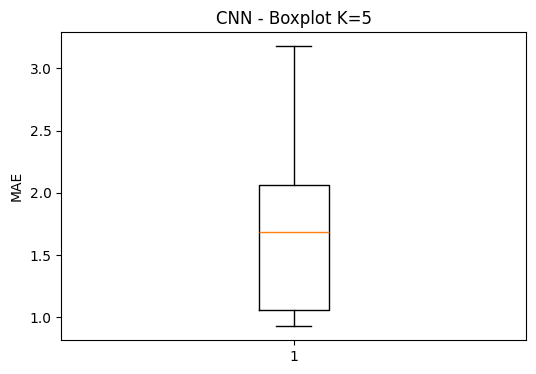

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(results_df["mae"])
plt.ylabel("MAE")
plt.title("CNN - Boxplot K=5")

plt.show()

In [ ]:
pred_df = pd.DataFrame({
    "DAP_real": all_targets,
    "DAP_predito": all_predictions,
    "Fold": all_folds
})
display(pred_df)

,DAP_real,DAP_predito,Fold
0,17.600000,15.873241,1
1,17.000000,14.535997,1
2,17.400000,16.534931,1
3,13.800000,15.856802,2
4,13.800000,17.875336,2
5,17.799999,17.737650,2
6,16.799999,15.474154,3
7,12.900000,16.818924,3
8,20.400000,16.110460,3
9,16.700001,16.693184,4


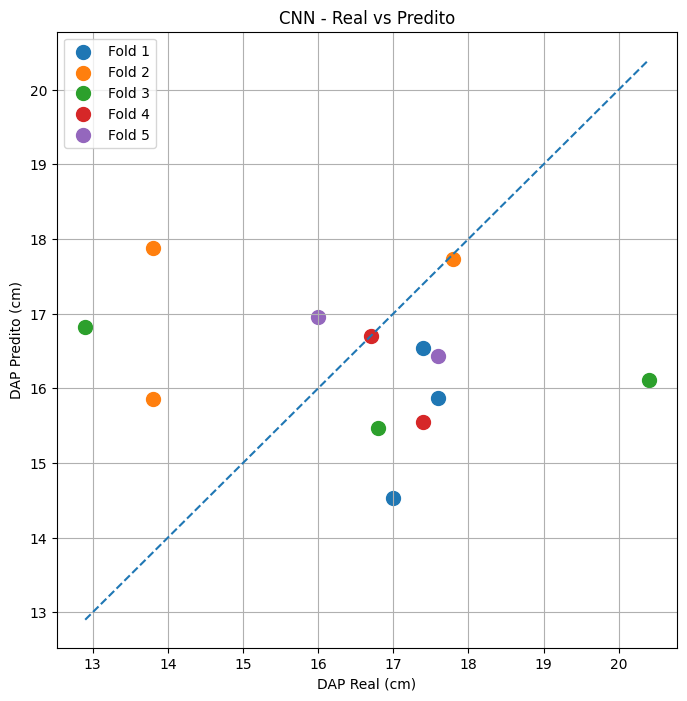

In [ ]:
plt.figure(figsize=(8,8))

for fold in sorted(
    pred_df["Fold"].unique()
):

    temp = pred_df[
        pred_df["Fold"] == fold
    ]

    plt.scatter(
        temp["DAP_real"],
        temp["DAP_predito"],
        label=f"Fold {fold}",
        s=100
    )

xmin = pred_df["DAP_real"].min()
xmax = pred_df["DAP_real"].max()

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    '--'
)

plt.xlabel("DAP Real (cm)")
plt.ylabel("DAP Predito (cm)")

plt.title(
    "CNN - Real vs Predito"
)

plt.legend()
plt.grid()
plt.show()

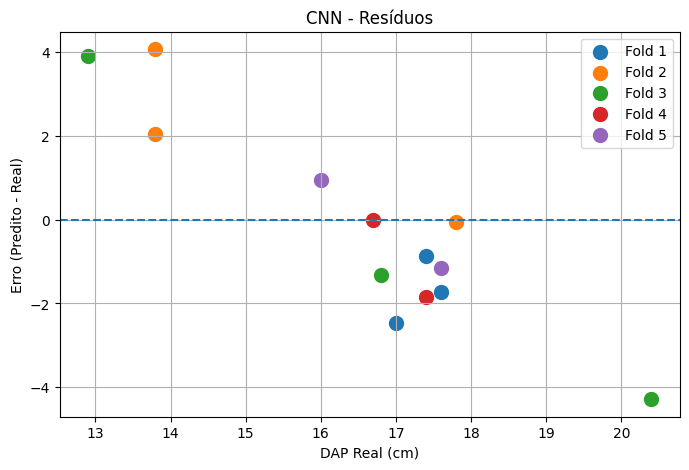

In [ ]:
pred_df["erro"] = (
    pred_df["DAP_predito"]
    -
    pred_df["DAP_real"]
)

plt.figure(figsize=(8,5))

for fold in sorted(
    pred_df["Fold"].unique()
):

    temp = pred_df[
        pred_df["Fold"] == fold
    ]

    plt.scatter(
        temp["DAP_real"],
        temp["erro"],
        label=f"Fold {fold}",
        s=100
    )

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("DAP Real (cm)")
plt.ylabel("Erro (Predito - Real)")

plt.title(
    "CNN - Resíduos"
)

plt.legend()
plt.grid()
plt.show()

In [ ]:
import json
import paho.mqtt.client as mqtt

MQTT_HOST = "andromeda.lasdpc.icmc.usp.br"
MQTT_PORT = 5163
MQTT_TOPIC = "grupo3/modelos/metricas"

modelo_ia = "CNN"
cenario = "Cenario 1"

dados = {
    "modelo_ia": modelo_ia,
    "cenario": cenario,
    "mae": float(summary.loc["mae", "Media"]),
    "mape": float(summary.loc["mape", "Media"]),
    "rrmse": float(summary.loc["rrmse", "Media"]),
    "bias": float(summary.loc["bias", "Media"]),
    "tempo_inferencia": float(summary.loc["latency", "Media"]),
    "throughput": float(summary.loc["throughput", "Media"])
}

client = mqtt.Client(
    mqtt.CallbackAPIVersion.VERSION2,
    transport="websockets"
)

client.ws_set_options(path="/mqtt")
client.connect(MQTT_HOST, MQTT_PORT, 60)
client.publish(MQTT_TOPIC, json.dumps(dados))
client.disconnect()

print("Mensagem MQTT enviada pela porta 5163 via WebSocket.")
print(dados)